In [1]:
import os
import json
import pandas as pd
import ast
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score

In [ ]:
NOTEBOOK_DIR= os.getcwd()
BASE_DIR= os.path.join(NOTEBOOK_DIR, "..")
pubmedqa = os.path.join(BASE_DIR, "data", "external", "pubmedqa", "pubmedqa.csv")
medqa = os.path.join(BASE_DIR, "data", "external", "medqa", "textbooks")
bioasq = os.path.join(BASE_DIR, "data", "external", "bioasq", "task_b", "bioasq.csv")
medmcqa = os.path.join(BASE_DIR, "data", "external", "medmcqa", "original.json")

### 

### PubMedQA

In [4]:
df= pd.read_csv(pubmedqa)

df["context"] = df["context"].apply(ast.literal_eval)

num_abstract= len(df)
abstract_data= []
for _, r  in df.iterrows():
    l= r["context"]["contexts"]
    l= " ".join(l)
    l_len= len(l)
    abstract_data.append(l_len)

print(f"Number of abstracts: {num_abstract}")
print(f"Word average in an abstract: {sum(abstract_data)/num_abstract}")

Number of abstracts: 273518
Word average in an abstract: 1362.237655291425


In [5]:
df['context'].iloc[0]

{'contexts': ['Chronic rhinosinusitis (CRS) is a heterogeneous disease with an uncertain pathogenesis. Group 2 innate lymphoid cells (ILC2s) represent a recently discovered cell population which has been implicated in driving Th2 inflammation in CRS; however, their relationship with clinical disease characteristics has yet to be investigated.',
  'The aim of this study was to identify ILC2s in sinus mucosa in patients with CRS and controls and compare ILC2s across characteristics of disease.',
  'A cross-sectional study of patients with CRS undergoing endoscopic sinus surgery was conducted. Sinus mucosal biopsies were obtained during surgery and control tissue from patients undergoing pituitary tumour resection through transphenoidal approach. ILC2s were identified as CD45(+) Lin(-) CD127(+) CD4(-) CD8(-) CRTH2(CD294)(+) CD161(+) cells in single cell suspensions through flow cytometry. ILC2 frequencies, measured as a percentage of CD45(+) cells, were compared across CRS phenotype, endo

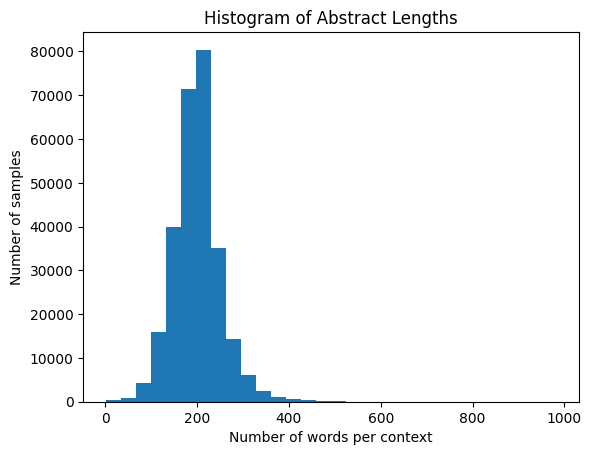

In [15]:
context_lengths = []

for item in df['context']:
    if isinstance(item, dict) and 'contexts' in item:
        texts = item['contexts']
        total_words = sum(len(t.split()) for t in texts)
        context_lengths.append(total_words)

plt.figure()
plt.hist(context_lengths, bins=30)
plt.xlabel("Number of words per context")
plt.ylabel("Number of samples")
plt.title("Histogram of Abstract Lengths")
plt.show()

### MedQA textbooks

In [16]:
txt_files = [f for f in os.listdir(medqa) if f.endswith(".txt")]

book_counts= len(txt_files)

book_word_counts = {}
for filename in txt_files:
    with open(os.path.join(medqa, filename), "r") as f:
        raw_lines = f.readlines()
    
    total_words = sum(len(line.split()) for line in raw_lines)
    book_word_counts[filename] = total_words
    print(f"{filename}: {total_words:,} words")

avg_words = sum(book_word_counts.values()) / book_counts
print(f"\nAverage words per textbook: {avg_words:,.0f}")

Pharmacology_Katzung.txt: 730,734 words
Surgery_Schwartz.txt: 1,601,640 words
Immunology_Janeway.txt: 498,650 words
First_Aid_Step1.txt: 89,908 words
Obstentrics_Williams.txt: 958,801 words
Psichiatry_DSM-5.txt: 418,604 words
Histology_Ross.txt: 462,808 words
Neurology_Adams.txt: 1,266,188 words
InternalMed_Harrison.txt: 3,206,314 words
Pathoma_Husain.txt: 57,413 words
Cell_Biology_Alberts.txt: 754,863 words
Gynecology_Novak.txt: 816,205 words
Physiology_Levy.txt: 408,117 words
Anatomy_Gray.txt: 352,200 words
Biochemistry_Lippincott.txt: 203,998 words
First_Aid_Step2.txt: 146,337 words
Pathology_Robbins.txt: 453,577 words
Pediatrics_Nelson.txt: 425,380 words

Average words per textbook: 713,985


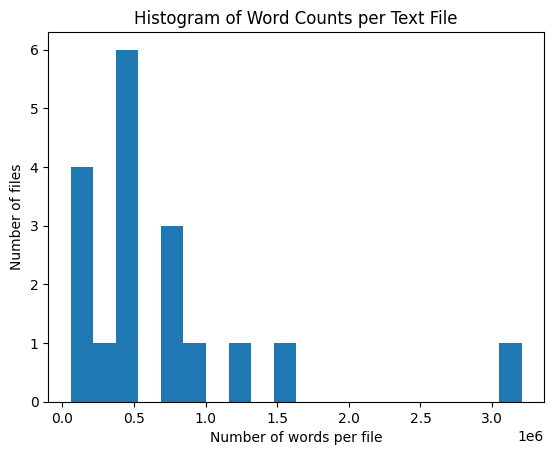

In [ ]:
word_counts = list(book_word_counts.values())

plt.figure()
plt.hist(word_counts, bins=20)
plt.xlabel("Number of words per file")
plt.ylabel("Number of files")
plt.title("Histogram of Word Counts per Text File")
plt.show()

### MedMCQA

In [3]:
df = pd.read_json(medmcqa, lines = True)

In [7]:
df.shape

(4183, 11)

In [6]:
df.head(2)

,question,exp,cop,opa,opb,opc,opd,subject_name,topic_name,id,choice_type
0,Which of the following is not true for myelina...,None,1,Impulse through myelinated fibers is slower th...,Membrane currents are generated at nodes of Ra...,Saltatory conduction of impulses is seen,Local anesthesia is effective only when the ne...,Physiology,None,45258d3d-b974-44dd-a161-c3fccbdadd88,multi
1,Which of the following is not true about glome...,Ans-a. The oncotic pressure of the fluid leavi...,1,The oncotic pressure of the fluid leaving the ...,Glucose concentration in the capillaries is th...,Constriction of afferent aeriole decreases the...,Hematocrit of the fluid leaving the capillarie...,Physiology,None,b944ada9-d776-4c2a-9180-3ae5f393f72d,multi


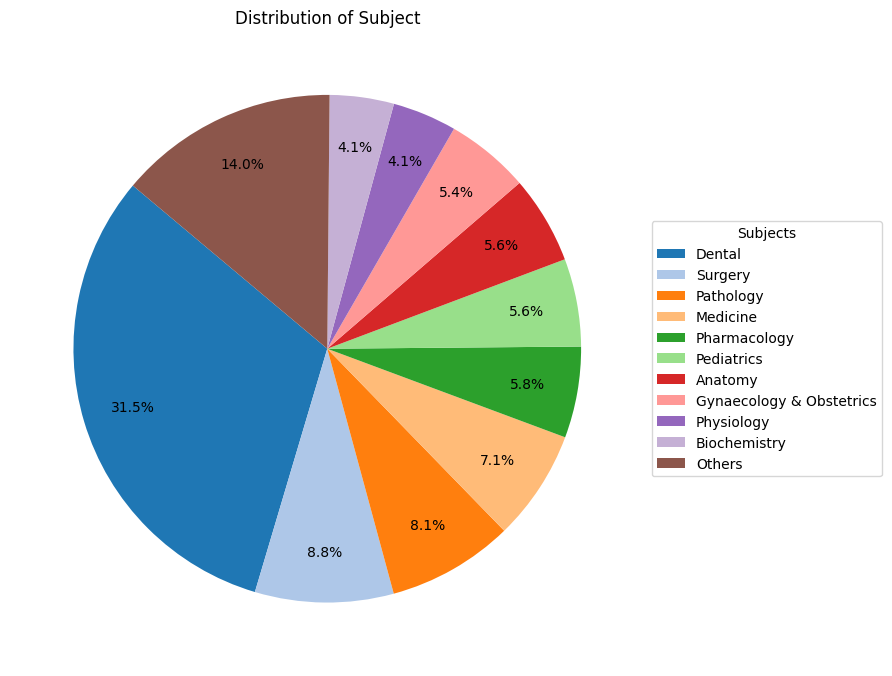

In [5]:
import matplotlib.pyplot as plt

# Prepare data
counts = df['subject_name'].value_counts().sort_values(ascending=False)

TOP_N = 10
top_counts = counts[:TOP_N]
other_counts = counts[TOP_N:].sum()

if other_counts > 0:
    top_counts['Others'] = other_counts

# Custom autopct function
def autopct_func(pct):
    return f'{pct:.1f}%' if pct > 4 else ''

# Colormap
cmap = plt.get_cmap('tab20')
colors = cmap(range(len(top_counts)))

plt.figure(figsize=(9, 9))

wedges, texts, autotexts = plt.pie(
    top_counts,
    labels=None,
    autopct=autopct_func,   # ✅ conditional percentages
    startangle=140,
    colors=colors,
    pctdistance=0.8,
    textprops={'fontsize': 10}
)

# Legend
plt.legend(
    wedges,
    top_counts.index,
    title="Subjects",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

plt.title("Distribution of Subject")
plt.tight_layout()
plt.show()

### Eval

In [4]:
medmcqa = os.path.join(BASE_DIR, "data", "processed", "medmcqa", "medmcqa.json")

In [8]:
with open(medmcqa, 'r') as f:
    df = pd.DataFrame(json.load(f))

In [ ]:
import random

def gen_rand():
    characters = "ABCD"
    random_code = random.choices(characters, k=1)
    return random_code[0]

df['synth'] = df.apply(lambda _: gen_rand(), axis=1)

In [18]:
df

,question,answer,synth
0,Which of the following is not true for myelina...,A,D
1,Which of the following is not true about glome...,A,B
2,A 29 yrs old woman with a pregnancy of 17 week...,C,D
3,Axonal transport is:\n\nA. Antegrade\nB. Retro...,C,A
4,Low insulin to glucagon ratio is seen in all o...,A,C
...,...,...,...
4178,A study is to be conducted with regards to the...,A,B
4179,"APGAR acronym stands for?\n\nA. Activity, puls...",D,B
4180,Most commonly implicated drug for acute liver ...,A,C
4181,A 9 year old boy has steroid dependent nephrot...,B,B


In [22]:
print(f'Accuracy: {accuracy_score(df['answer'], df['synth'])}')
print(f'Precision: {precision_score(df['answer'], df['synth'], average = 'macro')}')
print(f'Recall: {recall_score(df['answer'], df['synth'], average = 'macro')}')

Accuracy: 0.24671288548888357
Precision: 0.24589678196186548
Recall: 0.2452658367923516
